# K-mer GO-split Checkpoint Error Analysis

This notebook performs error analysis for the three namespace-specific k-mer MLP checkpoints:

- `kmer_BPO_final.pt`
- `kmer_CCO_final.pt`
- `kmer_MFO_final.pt`

It follows the GO-split setup from `kmer_GO_split.ipynb`.

This notebook does **not** retrain the models.  
It only reloads saved checkpoints, runs validation inference, and analyzes errors.

Important note:

You do **not** need `kmer_dropout_0.3.pt` for this analysis.  
That file is an intermediate tuning checkpoint.  
For GO-split error analysis, we use the final namespace-specific checkpoints only.

## Step 0. Imports and Paths

In [1]:
import os
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import load_npz

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score

DATA_DIR = "data_processed_kmer"

CHECKPOINTS = {
    "BPO": "pt/kmer_BPO_final.pt",
    "CCO": "pt/kmer_CCO_final.pt",
    "MFO": "pt/kmer_MFO_final.pt",
}

OUTPUT_DIR = "kmer_error_analysis_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("DATA_DIR:", DATA_DIR)
print("CHECKPOINTS:", CHECKPOINTS)
print("OUTPUT_DIR:", OUTPUT_DIR)

DATA_DIR: data_processed_kmer
CHECKPOINTS: {'BPO': 'pt/kmer_BPO_final.pt', 'CCO': 'pt/kmer_CCO_final.pt', 'MFO': 'pt/kmer_MFO_final.pt'}
OUTPUT_DIR: kmer_error_analysis_outputs


## Step 1. Load Processed K-mer Data

### Why this step?
The `.pt` files only store model weights.  
To evaluate prediction errors, we still need the validation features and labels.

In [2]:
X_train = np.load(os.path.join(DATA_DIR, "X_train.npy"))
X_val = np.load(os.path.join(DATA_DIR, "X_val.npy"))

Y_train = load_npz(os.path.join(DATA_DIR, "Y_train.npz"))
Y_val = load_npz(os.path.join(DATA_DIR, "Y_val.npz"))

with open(os.path.join(DATA_DIR, "meta.pkl"), "rb") as f:
    meta = pickle.load(f)

go_terms = meta["go_terms"].tolist() if hasattr(meta["go_terms"], "tolist") else list(meta["go_terms"])

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("Y_train:", Y_train.shape)
print("Y_val:", Y_val.shape)
print("Number of GO terms:", len(go_terms))

assert Y_train.shape[1] == len(go_terms)
assert Y_val.shape[1] == len(go_terms)

X_train: (112455, 400)
X_val: (28114, 400)
Y_train: (112455, 31454)
Y_val: (28114, 31454)
Number of GO terms: 31454


## Step 2. Load GO Namespace Mapping

### Why this step?
The final GO-split models were trained separately for BPO, CCO, and MFO.  
We need to reconstruct the same column splits used during training.

In [3]:
TERMS_PATH = os.path.join("..", "cafa-5-protein-function-prediction", "Train", "train_terms.tsv")

if not os.path.exists(TERMS_PATH):
    raise FileNotFoundError(
        f"Cannot find train_terms.tsv at {TERMS_PATH}. "
        "Please update TERMS_PATH."
    )

terms_df = pd.read_csv(TERMS_PATH, sep="\t")

go_to_aspect = (
    terms_df[["term", "aspect"]]
    .drop_duplicates()
    .set_index("term")["aspect"]
    .to_dict()
)

bpo_idx = [i for i, go in enumerate(go_terms) if go_to_aspect.get(go) == "BPO"]
cco_idx = [i for i, go in enumerate(go_terms) if go_to_aspect.get(go) == "CCO"]
mfo_idx = [i for i, go in enumerate(go_terms) if go_to_aspect.get(go) == "MFO"]

namespace_indices = {
    "BPO": bpo_idx,
    "CCO": cco_idx,
    "MFO": mfo_idx,
}

namespace_go_terms = {
    "BPO": [go_terms[i] for i in bpo_idx],
    "CCO": [go_terms[i] for i in cco_idx],
    "MFO": [go_terms[i] for i in mfo_idx],
}

print("Total GO terms:", len(go_terms))
print("BPO labels:", len(bpo_idx))
print("CCO labels:", len(cco_idx))
print("MFO labels:", len(mfo_idx))
print("Check total:", len(bpo_idx) + len(cco_idx) + len(mfo_idx))

Total GO terms: 31454
BPO labels: 21279
CCO labels: 2957
MFO labels: 7218
Check total: 31454


## Step 3. Split Validation Labels by Namespace

In [4]:
Y_val_namespace = {
    "BPO": Y_val[:, bpo_idx],
    "CCO": Y_val[:, cco_idx],
    "MFO": Y_val[:, mfo_idx],
}

Y_train_namespace = {
    "BPO": Y_train[:, bpo_idx],
    "CCO": Y_train[:, cco_idx],
    "MFO": Y_train[:, mfo_idx],
}

for ns in ["BPO", "CCO", "MFO"]:
    print(ns, "Y_train:", Y_train_namespace[ns].shape, "Y_val:", Y_val_namespace[ns].shape)

BPO Y_train: (112455, 21279) Y_val: (28114, 21279)
CCO Y_train: (112455, 2957) Y_val: (28114, 2957)
MFO Y_train: (112455, 7218) Y_val: (28114, 7218)


## Step 4. Define Dataset and MLP Architecture

### Why this step?
Each `.pt` checkpoint stores weights only, so we rebuild the same MLP architecture before loading each checkpoint.

In [5]:
class ProteinKmerDataset(Dataset):
    def __init__(self, X, Y_sparse):
        self.X = X.astype(np.float32)
        self.Y = Y_sparse.tocsr()
        self.n_labels = self.Y.shape[1]

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = torch.from_numpy(self.X[idx])

        start = self.Y.indptr[idx]
        end = self.Y.indptr[idx + 1]
        pos_idx = self.Y.indices[start:end]

        y = torch.zeros(self.n_labels, dtype=torch.float32)
        y[pos_idx] = 1.0

        return x, y


class MLP(nn.Module):
    def __init__(self, input_dim, output_dim, hidden1=512, hidden2=256, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.BatchNorm1d(hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, output_dim)
        )

    def forward(self, x):
        return self.net(x)


def build_val_loader(X_val, Y_val_ns, batch_size=64):
    dataset = ProteinKmerDataset(X_val, Y_val_ns)
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=torch.cuda.is_available()
    )
    return dataset, loader


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = X_val.shape[1]

print("Device:", device)
print("input_dim:", input_dim)

Device: cpu
input_dim: 400


/global/home/users/yushanfu/esm_env/lib/python3.11/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12030). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## Step 5. Load Checkpoint and Infer Architecture

### Why this step?
If the saved model uses hidden sizes different from the default, we infer the hidden dimensions from the checkpoint weight shapes.

In [6]:
def load_checkpoint_state_dict(path):
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Checkpoint not found: {path}. "
            "Please make sure the .pt file is in the current directory."
        )

    checkpoint = torch.load(path, map_location="cpu")

    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        return checkpoint["model_state_dict"]
    elif isinstance(checkpoint, dict):
        return checkpoint
    else:
        raise ValueError("Unsupported checkpoint format.")


def infer_mlp_dims_from_state_dict(state_dict):
    if "net.0.weight" in state_dict and "net.4.weight" in state_dict:
        hidden1 = state_dict["net.0.weight"].shape[0]
        hidden2 = state_dict["net.4.weight"].shape[0]
    else:
        linear_weight_keys = [
            k for k in state_dict.keys()
            if k.endswith("weight") and len(state_dict[k].shape) == 2
        ]
        hidden1 = state_dict[linear_weight_keys[0]].shape[0]
        hidden2 = state_dict[linear_weight_keys[1]].shape[0]

    return int(hidden1), int(hidden2)


def build_model_from_checkpoint(checkpoint_path, input_dim, output_dim, device, dropout=0.3):
    state_dict = load_checkpoint_state_dict(checkpoint_path)
    hidden1, hidden2 = infer_mlp_dims_from_state_dict(state_dict)

    model = MLP(
        input_dim=input_dim,
        output_dim=output_dim,
        hidden1=hidden1,
        hidden2=hidden2,
        dropout=dropout
    ).to(device)

    model.load_state_dict(state_dict)
    model.eval()

    return model, {"hidden1": hidden1, "hidden2": hidden2, "dropout": dropout}

## Step 6. Run Validation Inference for Each Namespace

### Why this step?
We only need a forward pass through the validation set.  
No training is performed here.

In [7]:
@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    all_probs = []
    all_targets = []

    for X_batch, Y_batch in loader:
        X_batch = X_batch.to(device, non_blocking=True)
        logits = model(X_batch)
        probs = torch.sigmoid(logits).cpu().numpy()

        all_probs.append(probs)
        all_targets.append(Y_batch.numpy())

    y_prob = np.vstack(all_probs)
    y_true = np.vstack(all_targets)

    return y_prob, y_true


predictions = {}
model_configs = {}

for ns in ["BPO", "CCO", "MFO"]:
    print("=" * 80)
    print(f"Loading and evaluating {ns}")
    print("=" * 80)

    _, val_loader = build_val_loader(X_val, Y_val_namespace[ns], batch_size=64)

    model, inferred_config = build_model_from_checkpoint(
        checkpoint_path=CHECKPOINTS[ns],
        input_dim=input_dim,
        output_dim=Y_val_namespace[ns].shape[1],
        device=device,
        dropout=0.3
    )

    y_prob, y_true = get_predictions(model, val_loader, device)

    predictions[ns] = {
        "y_prob": y_prob,
        "y_true": y_true,
    }

    model_configs[ns] = inferred_config

    np.save(os.path.join(OUTPUT_DIR, f"{ns}_y_prob.npy"), y_prob)
    np.save(os.path.join(OUTPUT_DIR, f"{ns}_y_true.npy"), y_true)

    print(ns, "y_prob:", y_prob.shape, "y_true:", y_true.shape)
    print(ns, "inferred config:", inferred_config)

Loading and evaluating BPO
BPO y_prob: (28114, 21279) y_true: (28114, 21279)
BPO inferred config: {'hidden1': 512, 'hidden2': 256, 'dropout': 0.3}
Loading and evaluating CCO
CCO y_prob: (28114, 2957) y_true: (28114, 2957)
CCO inferred config: {'hidden1': 512, 'hidden2': 256, 'dropout': 0.3}
Loading and evaluating MFO
MFO y_prob: (28114, 7218) y_true: (28114, 7218)
MFO inferred config: {'hidden1': 512, 'hidden2': 256, 'dropout': 0.3}


## Step 7. Threshold Sweep

### Why this step?
Error analysis requires binary predictions.  
We select the threshold that gives the best validation micro-F1 for each namespace.

In [8]:
BEST_THRESHOLDS = {
    "BPO": 0.75,
    "CCO": 0.75,
    "MFO": 0.85,
}

threshold_results = {}

for ns in ["BPO", "CCO", "MFO"]:
    y_prob = predictions[ns]["y_prob"]
    y_true = predictions[ns]["y_true"]

    selected_threshold = BEST_THRESHOLDS[ns]
    y_pred = (y_prob >= selected_threshold).astype(np.int8)

    micro = f1_score(y_true, y_pred, average="micro", zero_division=0)
    macro = f1_score(y_true, y_pred, average="macro", zero_division=0)

    threshold_results[ns] = {
        "selected_threshold": selected_threshold,
        "micro_f1": float(micro),
        "macro_f1": float(macro),
    }

    print("=" * 80)
    print(ns)
    print("Selected threshold:", selected_threshold)
    print("micro-F1:", micro)
    print("macro-F1:", macro)

BPO
Selected threshold: 0.75
micro-F1: 0.10085526079523256
macro-F1: 0.00972265857580832
CCO
Selected threshold: 0.75
micro-F1: 0.1463468320868456
macro-F1: 0.032351325050349294
MFO
Selected threshold: 0.85
micro-F1: 0.15183777531219755
macro-F1: 0.017538097836723984


## Step 8. Compute FP / FN / TP Error Summary

### Why this step?
This identifies whether each namespace model is more likely to over-predict or miss GO terms.

In [9]:
def compute_error_analysis_for_namespace(ns, y_true, y_prob, threshold, go_terms_ns):
    y_pred = (y_prob >= threshold).astype(np.int8)

    fp = (y_pred == 1) & (y_true == 0)
    fn = (y_pred == 0) & (y_true == 1)
    tp = (y_pred == 1) & (y_true == 1)

    fp_per_label = fp.sum(axis=0)
    fn_per_label = fn.sum(axis=0)
    tp_per_label = tp.sum(axis=0)

    true_count_per_label = y_true.sum(axis=0)
    pred_count_per_label = y_pred.sum(axis=0)

    summary = {
        "namespace": ns,
        "threshold": float(threshold),
        "total_tp": int(tp.sum()),
        "total_fp": int(fp.sum()),
        "total_fn": int(fn.sum()),
        "total_true_labels": int(y_true.sum()),
        "total_predicted_labels": int(y_pred.sum()),
        "avg_true_labels_per_protein": float(y_true.sum(axis=1).mean()),
        "avg_predicted_labels_per_protein": float(y_pred.sum(axis=1).mean()),
    }

    label_error_df = pd.DataFrame({
        "namespace": ns,
        "go_term": go_terms_ns,
        "true_count": true_count_per_label,
        "pred_count": pred_count_per_label,
        "tp": tp_per_label,
        "fp": fp_per_label,
        "fn": fn_per_label,
    })

    label_error_df["fn_rate"] = label_error_df["fn"] / (label_error_df["true_count"] + 1e-12)
    label_error_df["fp_rate"] = label_error_df["fp"] / (label_error_df["pred_count"] + 1e-12)

    return summary, label_error_df


error_summaries = []
label_error_tables = {}

for ns in ["BPO", "CCO", "MFO"]:
    y_true = predictions[ns]["y_true"]
    y_prob = predictions[ns]["y_prob"]
    threshold = threshold_results[ns]["selected_threshold"]

    summary, label_error_df = compute_error_analysis_for_namespace(
        ns=ns,
        y_true=y_true,
        y_prob=y_prob,
        threshold=threshold,
        go_terms_ns=namespace_go_terms[ns],
    )

    error_summaries.append(summary)
    label_error_tables[ns] = label_error_df

    label_error_df.to_csv(
        os.path.join(OUTPUT_DIR, f"{ns}_per_label_error_table.csv"),
        index=False
    )

error_summary_df = pd.DataFrame(error_summaries)
display(error_summary_df)

error_summary_df.to_csv(
    os.path.join(OUTPUT_DIR, "namespace_error_summary.csv"),
    index=False
)

,namespace,threshold,total_tp,total_fp,total_fn,total_true_labels,total_predicted_labels,avg_true_labels_per_protein,avg_predicted_labels_per_protein
0,BPO,0.75,92676,1055757,596693,689369,1148433,24.520489,40.849150
1,CCO,0.75,43881,317411,194512,238393,361292,8.479512,12.850964
2,MFO,0.85,19296,101504,114070,133366,120800,4.743758,4.296792


## Step 9. Plot Error Counts by Namespace

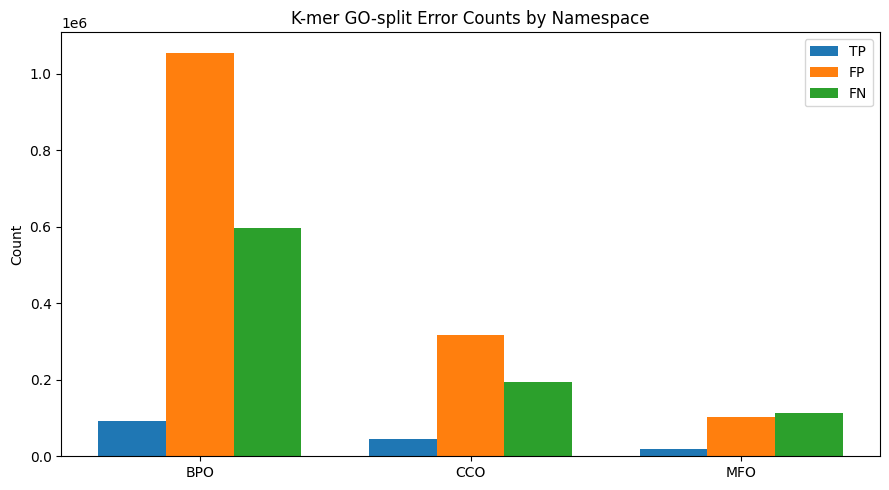

In [10]:
x = np.arange(len(error_summary_df))
width = 0.25

plt.figure(figsize=(9, 5))
plt.bar(x - width, error_summary_df["total_tp"], width=width, label="TP")
plt.bar(x, error_summary_df["total_fp"], width=width, label="FP")
plt.bar(x + width, error_summary_df["total_fn"], width=width, label="FN")

plt.xticks(x, error_summary_df["namespace"])
plt.ylabel("Count")
plt.title("K-mer GO-split Error Counts by Namespace")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "namespace_error_counts.png"), dpi=200, bbox_inches="tight")
plt.show()

## Step 10. Top False Negative GO Terms

### Interpretation
False negatives are GO terms that are truly present but missed by the model.

In [11]:
for ns in ["BPO", "CCO", "MFO"]:
    print("=" * 80)
    print(f"Top False Negative GO terms: {ns}")
    print("=" * 80)

    top_fn = (
        label_error_tables[ns][label_error_tables[ns]["true_count"] > 0]
        .sort_values("fn", ascending=False)
        .head(15)
    )

    display(top_fn[["go_term", "true_count", "pred_count", "tp", "fn", "fn_rate"]])

    top_fn.to_csv(
        os.path.join(OUTPUT_DIR, f"{ns}_top_false_negative_terms.csv"),
        index=False
    )

Top False Negative GO terms: BPO


,go_term,true_count,pred_count,tp,fn,fn_rate
2653,GO:0008150,18271.0,1218,1037,17234,0.943243
3304,GO:0009987,12184.0,0,0,12184,1.000000
13362,GO:0065007,8153.0,61,46,8107,0.994358
11212,GO:0050789,7699.0,95,73,7626,0.990518
11216,GO:0050794,6617.0,98,62,6555,0.990630
11286,GO:0050896,6144.0,58,34,6110,0.994466
2654,GO:0008152,6106.0,311,182,5924,0.970193
14224,GO:0071704,5657.0,263,144,5513,0.974545
9329,GO:0044237,5084.0,169,83,5001,0.983674
6472,GO:0032501,5663.0,1143,719,4944,0.873035


Top False Negative GO terms: CCO


,go_term,true_count,pred_count,tp,fn,fn_rate
176,GO:0005575,18430.0,1819,1462,16968,0.920673
2550,GO:0110165,18117.0,1592,1266,16851,0.930121
212,GO:0005622,14098.0,242,192,13906,0.986381
1554,GO:0043226,12103.0,894,626,11477,0.948277
1557,GO:0043229,11617.0,1102,756,10861,0.934923
278,GO:0005737,10686.0,22,14,10672,0.998690
1555,GO:0043227,11030.0,635,392,10638,0.964461
1559,GO:0043231,10425.0,893,542,9883,0.948010
217,GO:0005634,5737.0,3297,1627,4110,0.716402
641,GO:0016020,5105.0,2335,1166,3939,0.771596


Top False Negative GO terms: MFO


,go_term,true_count,pred_count,tp,fn,fn_rate
275,GO:0003674,15626.0,0,0,15626,1.000000
1409,GO:0005488,11462.0,0,0,11462,1.000000
1421,GO:0005515,9625.0,0,0,9625,1.000000
320,GO:0003824,4961.0,675,407,4554,0.917960
6337,GO:0097159,2523.0,305,109,2414,0.956797
6994,GO:1901363,2481.0,359,124,2357,0.950020
2694,GO:0016740,1959.0,326,107,1852,0.945380
276,GO:0003676,1989.0,817,268,1721,0.865259
2733,GO:0016787,1531.0,289,111,1420,0.927498
6755,GO:0140096,1422.0,269,122,1300,0.914205


## Step 11. Top False Positive GO Terms

### Interpretation
False positives are GO terms predicted by the model but not present in the ground truth.

In [12]:
for ns in ["BPO", "CCO", "MFO"]:
    print("=" * 80)
    print(f"Top False Positive GO terms: {ns}")
    print("=" * 80)

    top_fp = (
        label_error_tables[ns][label_error_tables[ns]["pred_count"] > 0]
        .sort_values("fp", ascending=False)
        .head(15)
    )

    display(top_fp[["go_term", "true_count", "pred_count", "tp", "fp", "fp_rate"]])

    top_fp.to_csv(
        os.path.join(OUTPUT_DIR, f"{ns}_top_false_positive_terms.csv"),
        index=False
    )

Top False Positive GO terms: BPO


,go_term,true_count,pred_count,tp,fp,fp_rate
2090,GO:0006886,284.0,6981,174,6807,0.975075
12516,GO:0060560,254.0,6954,150,6804,0.978430
7180,GO:0034248,250.0,5591,118,5473,0.978895
4453,GO:0016049,244.0,5082,122,4960,0.975994
4212,GO:0015031,416.0,4890,195,4695,0.960123
9634,GO:0045184,458.0,4480,199,4281,0.955580
17922,GO:1902532,220.0,4099,98,4001,0.976092
8381,GO:0040008,495.0,4139,200,3939,0.951679
7295,GO:0034470,270.0,3695,136,3559,0.963194
14687,GO:0072594,189.0,3583,79,3504,0.977951


Top False Positive GO terms: CCO


,go_term,true_count,pred_count,tp,fp,fp_rate
279,GO:0005739,1799.0,4896,994,3902,0.796977
2622,GO:0140513,803.0,3813,407,3406,0.893260
85,GO:0000785,443.0,3564,251,3313,0.929574
236,GO:0005667,242.0,3153,126,3027,0.960038
1039,GO:0031966,355.0,3242,217,3025,0.933066
830,GO:0030659,368.0,3193,169,3024,0.947072
615,GO:0012506,378.0,3145,169,2976,0.946264
280,GO:0005740,385.0,3142,224,2918,0.928708
257,GO:0005694,827.0,3258,413,2845,0.873235
1524,GO:0043005,651.0,2952,295,2657,0.900068


Top False Positive GO terms: MFO


,go_term,true_count,pred_count,tp,fp,fp_rate
5100,GO:0048018,155.0,1828,101,1727,0.944748
2710,GO:0016757,285.0,1806,181,1625,0.899779
3296,GO:0030546,158.0,1673,103,1570,0.938434
3295,GO:0030545,169.0,1638,106,1532,0.935287
3179,GO:0022857,935.0,1969,666,1303,0.661757
1285,GO:0005215,989.0,1929,667,1262,0.654225
3650,GO:0032555,277.0,1326,108,1218,0.918552
2875,GO:0017076,343.0,1258,112,1146,0.910970
56,GO:0000287,123.0,1168,41,1127,0.964897
1211,GO:0005102,555.0,1233,157,1076,0.872668


## Step 12. Label Frequency vs False Negative Rate

### Why this step?
GO terms with fewer positive examples are usually harder to predict.  
This plot checks whether rare labels have higher false negative rates.

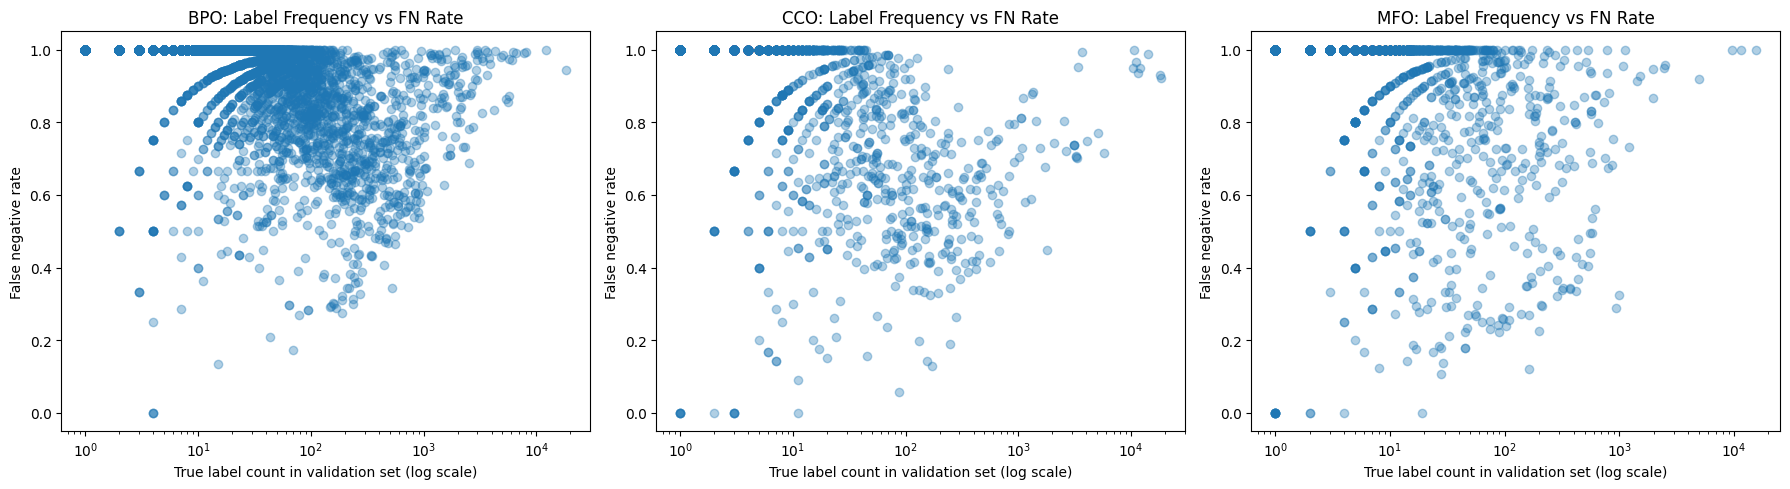

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, ns in zip(axes, ["BPO", "CCO", "MFO"]):
    plot_df = label_error_tables[ns].copy()
    plot_df = plot_df[plot_df["true_count"] > 0]

    ax.scatter(plot_df["true_count"], plot_df["fn_rate"], alpha=0.35)
    ax.set_xscale("log")
    ax.set_xlabel("True label count in validation set (log scale)")
    ax.set_ylabel("False negative rate")
    ax.set_title(f"{ns}: Label Frequency vs FN Rate")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "label_frequency_vs_fn_rate_by_namespace.png"), dpi=200, bbox_inches="tight")
plt.show()

## Step 13. Predicted vs True GO Count Distribution by Namespace

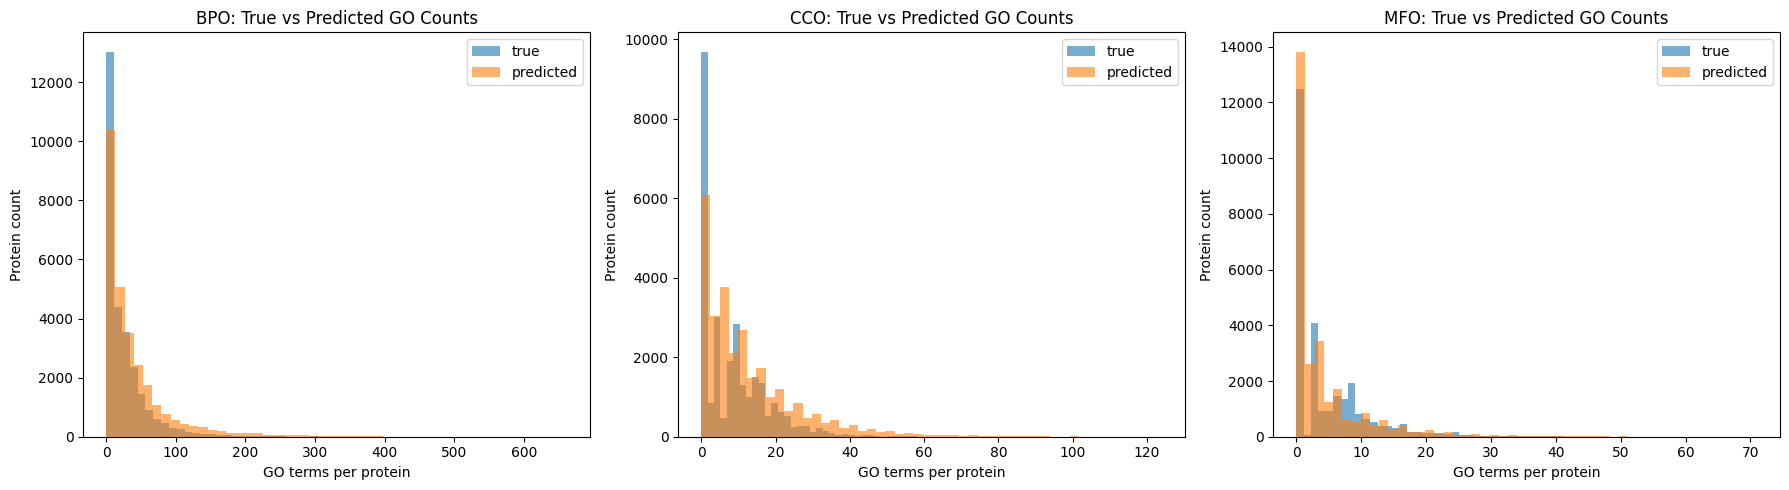

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, ns in zip(axes, ["BPO", "CCO", "MFO"]):
    y_true = predictions[ns]["y_true"]
    y_prob = predictions[ns]["y_prob"]
    threshold = threshold_results[ns]["selected_threshold"]
    y_pred = (y_prob >= threshold).astype(np.int8)

    true_counts = y_true.sum(axis=1)
    pred_counts = y_pred.sum(axis=1)

    ax.hist(true_counts, bins=50, alpha=0.6, label="true")
    ax.hist(pred_counts, bins=50, alpha=0.6, label="predicted")
    ax.set_title(f"{ns}: True vs Predicted GO Counts")
    ax.set_xlabel("GO terms per protein")
    ax.set_ylabel("Protein count")
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "true_vs_predicted_go_count_by_namespace.png"), dpi=200, bbox_inches="tight")
plt.show()

## Step 14. Save Combined Error Table

In [15]:
combined_label_error_df = pd.concat(
    [label_error_tables[ns] for ns in ["BPO", "CCO", "MFO"]],
    ignore_index=True
)

combined_label_error_df.to_csv(
    os.path.join(OUTPUT_DIR, "combined_per_label_error_table.csv"),
    index=False
)

summary = {
    "checkpoints": CHECKPOINTS,
    "model_configs_inferred_from_checkpoints": model_configs,
    "threshold_results": threshold_results,
    "error_summary": error_summary_df.to_dict(orient="records"),
}

with open(os.path.join(OUTPUT_DIR, "error_analysis_summary.json"), "w") as f:
    json.dump(summary, f, indent=2)

print("Saved all outputs to:", OUTPUT_DIR)

Saved all outputs to: kmer_error_analysis_outputs


## Summary

This notebook analyzes the final k-mer GO-split checkpoints:

- `kmer_BPO_final.pt`
- `kmer_CCO_final.pt`
- `kmer_MFO_final.pt`

It does not use `kmer_dropout_0.3.pt`, because that file is an intermediate tuning checkpoint rather than the final namespace-specific model.

The error analysis identifies:
- total TP / FP / FN by namespace
- top false negative GO terms
- top false positive GO terms
- whether rare GO terms tend to have higher false negative rates
- whether each namespace model over-predicts or under-predicts GO labels